In [1]:
%pip install pandas numpy matplotlib scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Step 3: Split features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [5]:
# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# Step 6: Initialize and train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Step 7: Make predictions
y_pred = knn.predict(X_test)

In [7]:

# Step 8: Evaluate performance
print("\n✅ Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


✅ Model Evaluation:
Accuracy: 0.6623376623376623

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.71      0.73        99
           1       0.52      0.58      0.55        55

    accuracy                           0.66       154
   macro avg       0.64      0.64      0.64       154
weighted avg       0.67      0.66      0.67       154



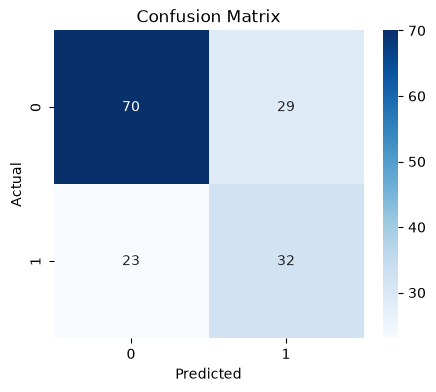

In [8]:
# Step 9: Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Neighbors: 1
Accuracy: 0.6753246753246753
Neighbors: 2
Accuracy: 0.7012987012987013
Neighbors: 3
Accuracy: 0.6493506493506493
Neighbors: 4
Accuracy: 0.7077922077922078
Neighbors: 5
Accuracy: 0.6623376623376623
Neighbors: 6
Accuracy: 0.7272727272727273
Neighbors: 7
Accuracy: 0.6883116883116883
Neighbors: 8
Accuracy: 0.7467532467532467
Neighbors: 9
Accuracy: 0.7207792207792207
Neighbors: 10
Accuracy: 0.7662337662337663
Neighbors: 11
Accuracy: 0.7337662337662337
Neighbors: 12
Accuracy: 0.7792207792207793
Neighbors: 13
Accuracy: 0.7727272727272727
Neighbors: 14
Accuracy: 0.7727272727272727
Neighbors: 15
Accuracy: 0.7597402597402597
Neighbors: 16
Accuracy: 0.7792207792207793
Neighbors: 17
Accuracy: 0.7727272727272727
Neighbors: 18
Accuracy: 0.7597402597402597
Neighbors: 19
Accuracy: 0.7532467532467533
Neighbors: 20
Accuracy: 0.7272727272727273


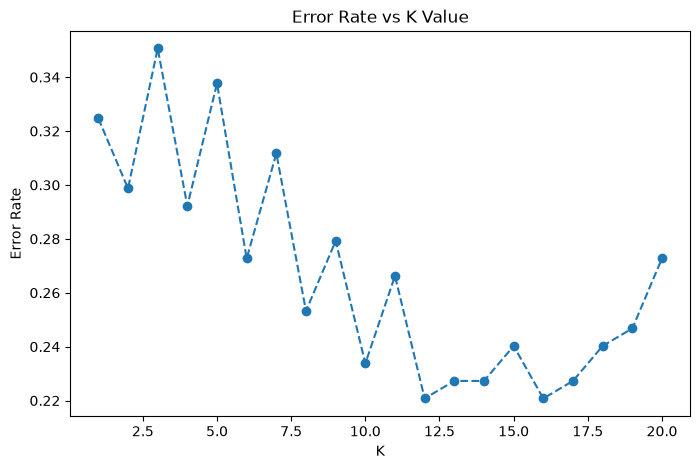

In [9]:
# Step 10: (Optional) Tune 'k' to find the best value
error_rate = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    print("Neighbors:", k)
    print("Accuracy:", accuracy_score(y_test, pred_k))
    error_rate.append(np.mean(pred_k != y_test))

plt.figure(figsize=(8,5))
plt.plot(range(1,21), error_rate, marker='o', linestyle='dashed')
plt.title('Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

In [10]:
# Step 6: Initialize and train the KNN model
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train, y_train)

# Step 7: Make predictions
y_pred = knn.predict(X_test)

In [11]:
# Step 8: Evaluate performance
print("\n✅ Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


✅ Model Evaluation:
Accuracy: 0.7077922077922078

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.83      0.78        99
           1       0.61      0.49      0.55        55

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [12]:
# [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age]
sample = np.array([[2, 120, 70, 25, 80, 30.5, 0.4, 35]])

# Predict
prediction = knn.predict(sample)[0]

# Output result
if prediction == 1:
    print("🩺 The model predicts: Diabetes detected (Positive)")
else:
    print("✅ The model predicts: No diabetes (Negative)")

✅ The model predicts: No diabetes (Negative)


c:\Users\ROMEO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [13]:
%pip install pickle

import pickle
# Save the model to a file
with open('knn_diabetes_model.pkl', 'wb') as file:
    pickle.dump(knn, file)

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle
